# Newton's Method

A guided notebook transcribed and expanded from the Coursera
*Calculus for Machine Learning and Data Science* lecture on **Newton's method**
(Week 3 — Optimization in Neural Networks and Newton's Method).

This notebook explains:

- Newton's method as a fast way to find the **zeros** of a function
- the geometric idea (follow the tangent to the x-axis) and the update
  $x_{k+1} = x_k - \dfrac{f(x_k)}{f'(x_k)}$
- how to **adapt it for optimization**: minimize $g$ by finding the zeros of $g'$, giving
  $x_{k+1} = x_k - \dfrac{g'(x_k)}{g''(x_k)}$
- implementations, a $\sqrt{2}$ demo, and a head-to-head with gradient descent

This notebook follows the repository `GUIDELINES.md` template and continues the Week 3
material after gradient descent and backpropagation.

## 1. Introduction

> *"Newton's method is also very fast and very powerful. In principle it's used to find the
> zeros of a function, but we can adapt it for optimization. It works in many variables as
> well."*

We start in one variable: given $f$, find the point where $f(x) = 0$.

After this notebook you will be able to:

- run Newton's method to find a root
- derive its update from the tangent line
- adapt it to minimize a function using the first and second derivatives

## 2. The geometric idea (root finding)

Start at a guess $x_0$ (not the root). Draw the **tangent** at $x_0$ and see where it
crosses the x-axis — call that $x_1$. It is much closer to the root. Iterate: each tangent
step lands nearer the zero, and after just a few steps you are essentially there.

## 3. Deriving the update

The tangent at $x_0$ has slope $f'(x_0)$. Reading "rise over run" on the triangle whose
height is $f(x_0)$ and base is $x_0 - x_1$:

$$
f'(x_0) = \frac{f(x_0)}{x_0 - x_1}
\quad\Longrightarrow\quad
x_1 = x_0 - \frac{f(x_0)}{f'(x_0)} .
$$

Repeating from any iterate $x_k$ gives **Newton's method**:

$$
\boxed{\;x_{k+1} = x_k - \dfrac{f(x_k)}{f'(x_k)}.\;}
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def newton_root(f, fprime, x0, n_iter=20, tol=1e-12):
    x = float(x0)
    history = [x]
    for _ in range(n_iter):
        step = f(x) / fprime(x)
        x = x - step
        history.append(x)
        if abs(step) < tol:
            break
    return x, np.array(history)

# classic example: find sqrt(2) as the positive root of f(x) = x^2 - 2
f      = lambda x: x**2 - 2
fprime = lambda x: 2*x

root, hist = newton_root(f, fprime, x0=2.0)
print(f"Newton root of x^2-2: {root:.12f}")
print(f"true sqrt(2):         {np.sqrt(2):.12f}")
print("iterates:", np.round(hist, 10))

Newton root of x^2-2: 1.414213562373
true sqrt(2):         1.414213562373
iterates: [2.         1.5        1.41666667 1.41421569 1.41421356 1.41421356
 1.41421356]


### Watching the tangents march to the root

Each tangent line crosses the x-axis closer to $\sqrt{2}$ than the last — convergence is
very fast (it roughly *doubles* the correct digits each step).

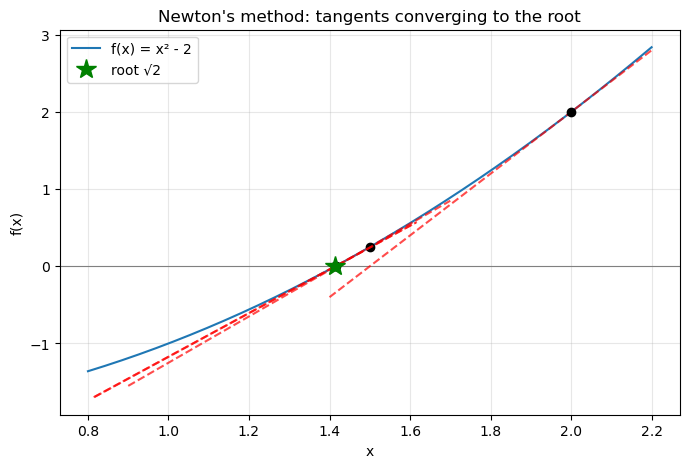

In [2]:
xs = np.linspace(0.8, 2.2, 200)
plt.figure(figsize=(8, 5))
plt.plot(xs, f(xs), label="f(x) = x² - 2")
plt.axhline(0, color="gray", lw=0.8)

for xk in hist[:4]:
    # tangent at xk
    t = np.linspace(xk - 0.6, xk + 0.2, 10)
    plt.plot(t, f(xk) + fprime(xk)*(t - xk), "r--", alpha=0.7)
    plt.plot(xk, f(xk), "ko")
plt.plot(np.sqrt(2), 0, "g*", markersize=15, label="root √2")
plt.title("Newton's method: tangents converging to the root")
plt.xlabel("x"); plt.ylabel("f(x)")
plt.grid(True, alpha=0.3); plt.legend()
plt.show()

## 4. From roots to optimization

> *"Newton's method finds the zero of a function, not the minimum. But to minimize $g(x)$
> you have to find the zeros of $g'(x)$."*

So set $f = g'$. Finding the zeros of $f$ then locates the **critical points** of $g$. Since
$f' = g''$, Newton's method becomes

$$
\boxed{\;x_{k+1} = x_k - \dfrac{g'(x_k)}{g''(x_k)}.\;}
$$

Note the **second derivative** $g''$ — this is the one-variable version of the **Hessian**
that appears in the multivariable case (next lectures).

In [3]:
def newton_optimize(gprime, gsecond, x0, n_iter=50, tol=1e-12):
    x = float(x0)
    history = [x]
    for _ in range(n_iter):
        step = gprime(x) / gsecond(x)
        x = x - step
        history.append(x)
        if abs(step) < tol:
            break
    return x, np.array(history)

# minimize g(x) = e^x - ln x  (the example from the gradient-descent lecture)
g       = lambda x: np.exp(x) - np.log(x)
gprime  = lambda x: np.exp(x) - 1/x
gsecond = lambda x: np.exp(x) + 1/x**2

x_min, hist_opt = newton_optimize(gprime, gsecond, x0=1.0)
print(f"Newton's minimum:        x = {x_min:.10f}")
print(f"Omega constant (true):   x = 0.5671432904")
print(f"iterations to converge:  {len(hist_opt) - 1}")
print("iterates:", np.round(hist_opt, 8))

Newton's minimum:        x = 0.5671432904
Omega constant (true):   x = 0.5671432904
iterations to converge:  5
iterates: [1.         0.53788284 0.56627701 0.56714258 0.56714329 0.56714329]


## 5. Newton vs. gradient descent

For the same function $g(x) = e^x - \ln x$, gradient descent needed hundreds of iterations;
Newton's method gets there in a handful. Newton converges **quadratically** (the number of
correct digits roughly doubles each step) — when it works, it is dramatically faster.

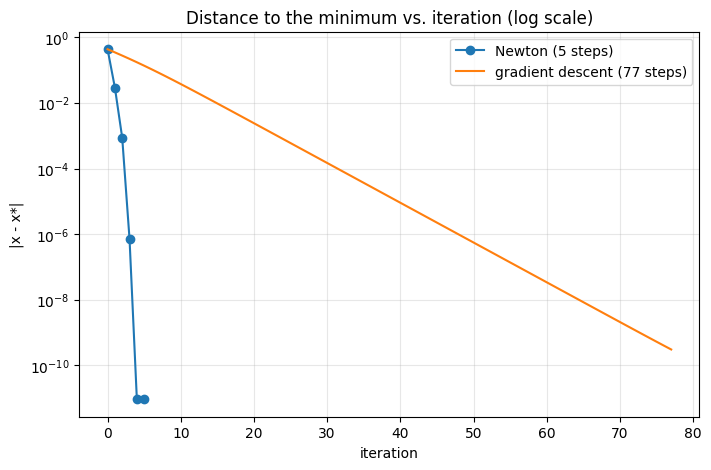

Newton reached the minimum in 5 steps; gradient descent took 77.


In [4]:
# gradient descent on the same function for comparison
def gradient_descent(gprime, x0, alpha=0.005, n_iter=5000, tol=1e-10):
    x = float(x0); hist = [x]
    for _ in range(n_iter):
        step = alpha * gprime(x)
        x -= step; hist.append(x)
        if abs(step) < tol:
            break
    return x, np.array(hist)

_, gd_hist = gradient_descent(gprime, x0=1.0, alpha=0.05)

err_newton = np.abs(hist_opt - 0.5671432904)
err_gd     = np.abs(gd_hist - 0.5671432904)

plt.figure(figsize=(8, 5))
plt.semilogy(err_newton, "o-", label=f"Newton ({len(hist_opt)-1} steps)")
plt.semilogy(err_gd, label=f"gradient descent ({len(gd_hist)-1} steps)")
plt.title("Distance to the minimum vs. iteration (log scale)")
plt.xlabel("iteration"); plt.ylabel("|x - x*|")
plt.grid(True, alpha=0.3, which="both"); plt.legend()
plt.show()

print(f"Newton reached the minimum in {len(hist_opt)-1} steps; "
      f"gradient descent took {len(gd_hist)-1}.")

## 6. Exercises

### Basic
1. Write Newton's update for finding a **root** of $f$.
2. Write Newton's update for **minimizing** $g$.

### Intermediate
3. Use Newton's method to find $\sqrt{5}$ as a root of $x^2 - 5$ from $x_0 = 2$.
4. Minimize $g(x) = x^2 - 4x + 7$ with Newton's method. How many steps does it need, and
   why?

### Advanced
5. Apply Newton's method to find a root of $f(x) = x^3 - x$ from $x_0 = 0.6$. Which root
   does it find? (Try $x_0 = 0.4$ too.)
6. Explain why Newton's optimization step needs the **second** derivative, and what could go
   wrong if $g''(x_k) = 0$.

## 7. Solutions / Checks

In [5]:
# 3. sqrt(5)
r5, _ = newton_root(lambda x: x**2-5, lambda x: 2*x, x0=2.0)
print(f"3. sqrt(5) ≈ {r5:.10f} (true {np.sqrt(5):.10f})")

# 4. quadratic -> one step (Newton is exact on quadratics)
xm, h4 = newton_optimize(lambda x: 2*x-4, lambda x: 2.0, x0=0.0)
print(f"4. min of x²-4x+7 at x={xm} in {len(h4)-1} step (Newton is exact for quadratics)")

# 5. cubic roots from different starts
for x0 in (0.6, 0.4):
    r, _ = newton_root(lambda x: x**3-x, lambda x: 3*x**2-1, x0=x0)
    print(f"5. x0={x0} -> root {r:.6f}")

print("1. x_{k+1} = x_k - f(x_k)/f'(x_k)")
print("2. x_{k+1} = x_k - g'(x_k)/g''(x_k)")
print("6. Minimizing means solving g'(x)=0, so we apply root-finding to g', whose own "
      "derivative is g''. If g''(x_k)=0 the step divides by zero and the method breaks.")

3. sqrt(5) ≈ 2.2360679775 (true 2.2360679775)
4. min of x²-4x+7 at x=2.0 in 2 step (Newton is exact for quadratics)
5. x0=0.6 -> root 1.000000
5. x0=0.4 -> root 0.000000
1. x_{k+1} = x_k - f(x_k)/f'(x_k)
2. x_{k+1} = x_k - g'(x_k)/g''(x_k)
6. Minimizing means solving g'(x)=0, so we apply root-finding to g', whose own derivative is g''. If g''(x_k)=0 the step divides by zero and the method breaks.


## 8. Conclusion

- **Newton's method** finds a root by following the tangent to the x-axis:
  $x_{k+1} = x_k - \dfrac{f(x_k)}{f'(x_k)}$.
- To **optimize** $g$, apply it to $f = g'$, giving
  $x_{k+1} = x_k - \dfrac{g'(x_k)}{g''(x_k)}$ — it needs the **second derivative**.
- It converges **quadratically**, far faster than gradient descent when it works (it found
  the Omega constant in a handful of steps).
- The cost is needing $g''$ (and, in many variables, the full **Hessian**) — the topic of
  the next lectures.

## Appendix — Source transcript

Transcribed with OpenAI Whisper (`small.en`) from a locally downloaded video
(`~/Downloads/new_01.mp4`), the Coursera *Calculus for Machine Learning and Data Science*
(Week 3) lecture on **Newton's method**. Key spoken points, lightly cleaned:

> Newton's method is a fast, powerful alternative to gradient descent. In principle it finds
> the zeros of a function, and it can be adapted for optimization and works in many
> variables. To find a zero of $f$: start at a random $x_0$, draw the tangent, and see where
> it hits the x-axis — that's $x_1$, closer to the zero; iterate and you converge fast. The
> slope is $f'(x_0) = f(x_0)/(x_0 - x_1)$, which rearranges to $x_1 = x_0 - f(x_0)/f'(x_0)$,
> and in general $x_{k+1} = x_k - f(x_k)/f'(x_k)$. For optimization, recall that minimizing
> $g(x)$ means finding the zeros of $g'(x)$; so let $f = g'$ (then $f' = g''$) and Newton's
> method becomes $x_{k+1} = x_k - g'(x_k)/g''(x_k)$. The second derivative will be a big
> deal soon. Iterate until you reach the root (or the minimum).